# Base Paper Prediction Models

## Crime Classification using Machine Learning

This notebook implements the BASE PAPER methodology using three models:

1. Naive Bayes
2. Random Tree
3. Meta/Multi-class Ensemble

The workflow is:

Load Data → Target & Feature Selection → Preprocessing → 
80/20 Train-Test Split → Model Training → Predictions → 
Evaluation → Final Comparison

In [2]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    cohen_kappa_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

In [3]:
# Load the existing integrated dataset

DATA_PATH = "../data/processed/district_integrated_final.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (9856, 331)


,STATE,UNIT_NAME,YEAR,IPC_MURDER,IPC_ATTEMPT_TO_MURDER,IPC_RAPE,IPC_OTHER_RAPE,IPC_KIDNAPPING_AND_ABDUCTION_OF_WOMEN_AND_GIRLS,IPC_KIDNAPPING_AND_ABDUCTION_OF_OTHERS,IPC_DACOITY,IPC_PREPARATION_AND_ASSEMBLY_FOR_DACOITY,IPC_ROBBERY,IPC_BURGLARY,IPC_THEFT,IPC_OTHER_THEFT,IPC_RIOTS,IPC_CHEATING,IPC_COUNTERFIETING,IPC_ARSON,IPC_HURT_GREVIOUS_HURT,IPC_INSULT_TO_MODESTY_OF_WOMEN,IPC_IMPORTATION_OF_GIRLS_FROM_FOREIGN_COUNTRIES,IPC_TOTAL_IPC_CRIMES,IPC_ATTEMPT_TO_COMMIT_MURDER,IPC_ATTEMPT_TO_COMMIT_CULPABLE_HOMICIDE,IPC_CUSTODIAL_GANG_RAPE,IPC_CUSTODIAL_OTHER_RAPE,IPC_RAPE_OTHER_THAN_CUSTODIAL,IPC_RAPE_GANG_RAPE,IPC_RAPE_OTHERS,IPC_ATTEMPT_TO_COMMIT_RAPE,IPC_KIDNAPPING_ABDUCTION_TOTAL,IPC_KIDNAPPING_ABDUCTION_IN_ORDER_TO_MURDER,IPC_KIDNAPPING_FOR_RANSOM,IPC_KIDNAPPING_ABDUCTION_OF_WOMEN_TO_COMPEL_HER_FOR_MARRIAGE,IPC_OTHER_KIDNAPPING,IPC_DACOITY_WITH_MURDER,IPC_OTHER_DACOITY,IPC_MAKING_PREPARATION_AND_ASSEMBLY_FOR_COMMITTING_DACOITY,IPC_CRIMINAL_TRESPASS_BURGLARY,IPC_CRIMINAL_TRESPASS_OR_BURGLARY,IPC_HOUSE_TRESPASS_HOUSE_BREAKING,IPC_OTHER_THEFTS,IPC_UNLAWFUL_ASSEMBLY,IPC_RIOTS_COMMUNAL,IPC_RIOTS_INDUSTRIAL,IPC_RIOTS_POLITICAL,IPC_RIOTS_CASTE_CONFLICT,IPC_RIOTS_SC_STS_VS_NON_SCS_STS,IPC_RIOTS_OTHER_CASTE_CONFLICT,IPC_RIOTS_AGRARIAN,IPC_RIOTS_STUDENTS,IPC_RIOTS_SECTARIAN,IPC_RIOTS_OTHERS,IPC_FORGERY,IPC_COUNTERFEITING,IPC_COUNTERFEIT_OFFENCES_RELATED_TO_COUNTERFEIT_COIN,IPC_COUNTERFEITING_GOVERNMENT_STAMP,IPC_COUNTERFEIT_CURRENCY_BANK_NOTES,IPC_COUNTERFEITING_CURRENCY_NOTES_BANK_NOTES,IPC_USING_FORGED_OR_COUNTERFEITING_CURRENCY_BANK_NOTES,IPC_POSSESSION_OF_FORGED_OR_COUNTERFEITING_CURRENCY_BANK_NOTES,IPC_MAKING_OR_POSSESSING_MATERIALS_FOR_FORGED_CURRENCY_BANK_NOTES,IPC_MAKING_OR_USING_DOCUMENTS_RESEMBLING_CURRENCY,IPC_GRIEVOUS_HURT,IPC_HURT,IPC_ACID_ATTACK,IPC_ATTEMPT_TO_ACID_ATTACK,IPC_SEXUAL_HARASSMENT,IPC_ASSAULT_OR_USE_OF_CRIMINAL_FORCE_TO_WOMEN_WITH_INTENT_TO_DISROBE,IPC_VOYEURISM,IPC_STALKING,IPC_OTHER_ASSAULT_ON_WOMEN,IPC_INSULT_TO_THE_MODESTY_OF_WOMEN,IPC_AT_OFFICE_PREMISES,IPC_OTHER_PLACES_RELATED_TO_WORK,IPC_IN_PUBLIC_TRANSPORT_SYSTEM,IPC_PLACES_OTHER_THAN_231_232_233,IPC_IMPORTATION_OF_GIRLS_FROM_FOREIGN_COUNTRY,IPC_DEATHS_DUE_TO_NEGLIGENT_DRIVING_ACT,IPC_DEATHS_DUE_TO_OTHER_CAUSES,IPC_OFFENCES_AGAINST_STATE,IPC_SEDITION,IPC_OTHER_OFFENCES_AGAINST_STATE,IPC_OFFENCES_PROMOTING_ENMITY_BETWEEN_DIFFERENT_GROUPS,IPC_PROMOTING_ENMITY_BETWEEN_DIFFERENT_GROUPS,IPC_IMPUTATION_ASSERTIONS_PREJUDICIAL_TO_NATIONAL_INTEGRATION,IPC_EXTORTION,IPC_DISCLOSURE_OF_IDENTITY_OF_VICTIMS,IPC_INCIDENCE_OF_RASH_DRIVING,IPC_HUMANTRAFFICKING,IPC_UNNATURAL_OFFENCE,IPC_TOTAL_COGNIZABLE_IPC_CRIMES,SC_MURDER,SC_RAPE,SC_KIDNAPPING_AND_ABDUCTION,SC_DACOITY,SC_ROBBERY,SC_ARSON,SC_HURT,SC_PREVENTION_OF_ATROCITIES_POA_ACT,SC_PROTECTION_OF_CIVIL_RIGHTS_PCR_ACT,SC_OTHER_CRIMES_AGAINST_SCS,SC_PROTECTION_OF_CIVIL_RIGHTS_ACT_1955,SC_POA_MURDER,SC_POA_ATTEMPT_TO_COMMIT_MURDER,SC_POA_RAPE,SC_POA_ATTEMPT_TO_COMMIT_RAPE,SC_POA_ASSAULT_ON_WOMEN_WITH_INTENT_TO_OUTRAGE_HER_MODESTY,SC_POA_SEXUAL_HARASSMENT,SC_POA_ASSAULT_ON_WOMEN_WITH_INTENT_TO_DISROBE,SC_POA_VOYEURISM,SC_POA_STALKING,SC_POA_OTHER_SEXUAL_HARASSMENT,SC_POA_INSULT_TO_THE_MODESTY_OF_WOMEN,SC_POA_KIDNAPPING_ABDUCTION_GRANDTOTAL,SC_POA_KIDNAPING_ABDUCTION_TOTAL,SC_POA_KIDNAPING_ABDUCTION_IN_ORDER_TO_MURDER,SC_POA_KIDNAPPING_FOR_RANSOM,SC_POA_KIDNAPPING_ABDUCTION_OF_WOMEN_TO_COMPEL_HER_FOR_MARRIAGE,SC_POA_OTHER_KIDNAPPING,SC_POA_DACOITY,SC_POA_DACOITY_WITH_MURDER,SC_POA_OTHER_DACOITY,SC_POA_ROBBERY,SC_POA_ARSON,SC_POA_GRIEVOUS_HURT,SC_POA_HURT,SC_POA_ACID_ATTACK,SC_POA_ATTEMPT_TO_ACID_ATTACK,SC_POA_RIOTS,SC_POA_OTHER_IPC_CRIMES,SC_POA_SC_ST_PREVENTION_OF_ATROCITIES_ACT_ONLY,SC_TOTAL_OF_SC_ST_PREVENTION_OF_ATROCITIES_ACT_1989,SC_IPC_MURDER,SC_IPC_ATTEMPT_TO_COMMIT_MURDER,SC_IPC_RAPE,SC_IPC_ATTEMPT_TO_COMMIT_RAPE,SC_IPC_ASSAULT_ON_WOMEN_WITH_INTENT_TO_OUTRAGE_HER_MODESTY,SC_IPC_SEXUAL_HARASSMENT,SC_IPC_ASSAULT_ON_WOMEN_WITH_INTENT_TO_DISROBE,SC_IPC_VOYEURISM,SC_IPC_STALKING,SC_IPC_OTHER_SEXUAL_HARASSMENT,SC_IPC_INS

In [4]:
# Inspect the actual dataset before selecting target/features

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 9856
Number of columns: 331

Column names:
['STATE', 'UNIT_NAME', 'YEAR', 'IPC_MURDER', 'IPC_ATTEMPT_TO_MURDER', 'IPC_RAPE', 'IPC_OTHER_RAPE', 'IPC_KIDNAPPING_AND_ABDUCTION_OF_WOMEN_AND_GIRLS', 'IPC_KIDNAPPING_AND_ABDUCTION_OF_OTHERS', 'IPC_DACOITY', 'IPC_PREPARATION_AND_ASSEMBLY_FOR_DACOITY', 'IPC_ROBBERY', 'IPC_BURGLARY', 'IPC_THEFT', 'IPC_OTHER_THEFT', 'IPC_RIOTS', 'IPC_CHEATING', 'IPC_COUNTERFIETING', 'IPC_ARSON', 'IPC_HURT_GREVIOUS_HURT', 'IPC_INSULT_TO_MODESTY_OF_WOMEN', 'IPC_IMPORTATION_OF_GIRLS_FROM_FOREIGN_COUNTRIES', 'IPC_TOTAL_IPC_CRIMES', 'IPC_ATTEMPT_TO_COMMIT_MURDER', 'IPC_ATTEMPT_TO_COMMIT_CULPABLE_HOMICIDE', 'IPC_CUSTODIAL_GANG_RAPE', 'IPC_CUSTODIAL_OTHER_RAPE', 'IPC_RAPE_OTHER_THAN_CUSTODIAL', 'IPC_RAPE_GANG_RAPE', 'IPC_RAPE_OTHERS', 'IPC_ATTEMPT_TO_COMMIT_RAPE', 'IPC_KIDNAPPING_ABDUCTION_TOTAL', 'IPC_KIDNAPPING_ABDUCTION_IN_ORDER_TO_MURDER', 'IPC_KIDNAPPING_FOR_RANSOM', 'IPC_KIDNAPPING_ABDUCTION_OF_WOMEN_TO_COMPEL_HER_FOR_MARRIAGE', 'IPC_OTHER_KIDNAPPI

In [5]:
# Check data types

print("Data types of columns:")

display(df.dtypes.value_counts())

print("\nCategorical columns:")

categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print(categorical_columns)

Data types of columns:


float64    323
bool         5
object       2
int64        1
Name: count, dtype: int64


Categorical columns:
['STATE', 'UNIT_NAME']


In [6]:
# Check missing values

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(
    ascending=False
)

print("Columns containing missing values:")

display(missing_values.head(20))

Columns containing missing values:


SC_OTHER_SLL_CRIME_AGAINST_SCS                                     9128
ST_POA_GRIEVOUS_HURT                                               9128
ST_POA_SC_ST_PREVENTION_OF_ATROCITIES_ACT_ONLY                     9128
ST_POA_OTHER_IPC_CRIMES                                            9128
ST_POA_RIOTS                                                       9128
ST_POA_ATTEMPT_TO_ACID_ATTACK                                      9128
ST_POA_ACID_ATTACK                                                 9128
ST_POA_HURT                                                        9128
ST_POA_ARSON                                                       9128
ST_IPC_MURDER                                                      9128
ST_POA_ROBBERY                                                     9128
ST_POA_OTHER_DACOITY                                               9128
ST_POA_DACOITY_WITH_MURDER                                         9128
ST_POA_DACOITY                                                  

In [7]:
# Identify crime-total related columns

crime_total_columns = [
    col for col in df.columns
    if "TOTAL" in col.upper()
]

print("Crime total-related columns:")

print(crime_total_columns)

Crime total-related columns:
['IPC_TOTAL_IPC_CRIMES', 'IPC_KIDNAPPING_ABDUCTION_TOTAL', 'IPC_TOTAL_COGNIZABLE_IPC_CRIMES', 'SC_POA_KIDNAPPING_ABDUCTION_GRANDTOTAL', 'SC_POA_KIDNAPING_ABDUCTION_TOTAL', 'SC_TOTAL_OF_SC_ST_PREVENTION_OF_ATROCITIES_ACT_1989', 'SC_TOTAL_IPC_CRIMES_AGAINST_SCS', 'SC_TOTAL_CRIMES_AGAINST_SCS', 'ST_POA_KIDNAPPING_ABDUCTION_GRANDTOTAL', 'ST_POA_KIDNAPING_ABDUCTION_TOTAL', 'ST_TOTAL_OF_SC_ST_PREVENTION_OF_ATROCITIES_ACT_1989', 'ST_TOTAL_IPC_CRIMES_AGAINST_STS', 'ST_TOTAL_CRIMES_AGAINST_STS', 'CHILDREN_TOTAL', 'WOMEN_KIDNAPPING_ABDUCTION_TOTAL', 'WOMEN_ASSAULT_ON_WOMEN_WITH_INTENT_TO_OUTRAGE_HER_MODESTY_TOTAL', 'WOMEN_INSULT_TO_THE_MODESTY_OF_WOMEN_TOTAL', 'WOMEN_DACOITY_TOTAL', 'WOMEN_TOTAL_CRIMES_AGAINST_WOMEN']


In [8]:
# Check the main total crime column

TARGET_SOURCE = "IPC_TOTAL_IPC_CRIMES"

print("Target source:", TARGET_SOURCE)

print("\nTarget source information:")
print(df[TARGET_SOURCE].describe())

print("\nMissing values:")
print(df[TARGET_SOURCE].isnull().sum())

Target source: IPC_TOTAL_IPC_CRIMES

Target source information:
count      8902.000000
mean       3090.330825
std        7845.477746
min           0.000000
25%         811.250000
50%        1947.500000
75%        3730.750000
max      234385.000000
Name: IPC_TOTAL_IPC_CRIMES, dtype: float64

Missing values:
954


## Target Selection

The dataset does not contain a ready-made classification label.

Therefore, `IPC_TOTAL_IPC_CRIMES` is used to derive a five-level crime-burden classification target.

The target will contain:

- Class 1 → Lowest crime burden
- Class 2 → Low-medium crime burden
- Class 3 → Medium crime burden
- Class 4 → Medium-high crime burden
- Class 5 → Highest crime burden

The original crime-total column will NOT be used as an input feature because
it is directly responsible for creating the target. This prevents target leakage.

In [9]:
# Keep only records where the target source is available

model_df = df.dropna(
    subset=[TARGET_SOURCE]
).copy()

print("Original dataset shape:", df.shape)
print("Dataset shape after removing missing target values:", model_df.shape)

Original dataset shape: (9856, 331)
Dataset shape after removing missing target values: (8902, 331)


In [10]:
# Create five approximately balanced crime-burden classes
# using quintiles of IPC_TOTAL_IPC_CRIMES

model_df["Crime_Level"] = pd.qcut(
    model_df[TARGET_SOURCE],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
).astype(int)

print("Crime Level distribution:")

display(
    model_df["Crime_Level"]
    .value_counts()
    .sort_index()
)

Crime Level distribution:


Crime_Level
1    1781
2    1780
3    1780
4    1780
5    1781
Name: count, dtype: int64

In [11]:
# Display the crime-count boundaries used to create the five classes

crime_boundaries = model_df[TARGET_SOURCE].quantile(
    [0, 0.20, 0.40, 0.60, 0.80, 1.00]
)

print("Crime level boundaries:")

display(crime_boundaries)

Crime level boundaries:


0.0         0.0
0.2       616.2
0.4      1431.4
0.6      2534.6
0.8      4251.8
1.0    234385.0
Name: IPC_TOTAL_IPC_CRIMES, dtype: float64

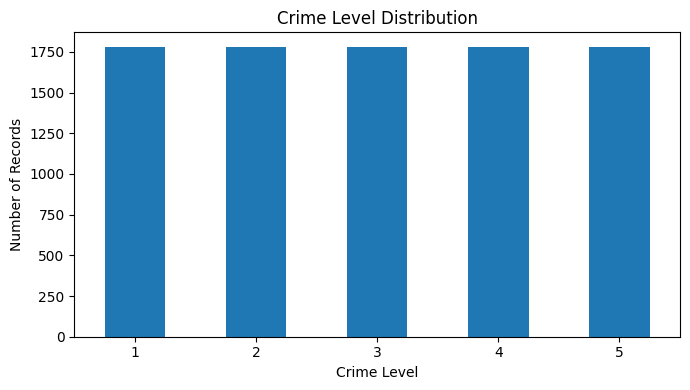

In [12]:
# Visualize target class distribution

plt.figure(figsize=(7, 4))

model_df["Crime_Level"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Crime Level Distribution")
plt.xlabel("Crime Level")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Feature Selection

The following features are selected:

### 1. STATE
Represents the geographical state associated with the record.

### 2. UNIT_NAME
Represents the district/police administrative unit.

### 3. YEAR
Represents the temporal variation in crime patterns.

### Excluded

`IPC_TOTAL_IPC_CRIMES` is excluded because it was used to create the target.

Other direct crime-count columns are also excluded because they could allow the
model to reconstruct the target directly and cause target leakage.

In [13]:
# Define input features

FEATURES = [
    "STATE",
    "UNIT_NAME",
    "YEAR"
]

TARGET = "Crime_Level"

# Check that all selected columns exist

missing_features = [
    col for col in FEATURES
    if col not in model_df.columns
]

if missing_features:
    raise ValueError(
        f"Missing feature columns: {missing_features}"
    )

# Create X and y

X = model_df[FEATURES].copy()

y = model_df[TARGET].copy()

print("Selected Features:")
print(FEATURES)

print("\nTarget:")
print(TARGET)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Selected Features:
['STATE', 'UNIT_NAME', 'YEAR']

Target:
Crime_Level

Feature shape: (8902, 3)
Target shape: (8902,)


,STATE,UNIT_NAME,YEAR
0,ANDHRA PRADESH,ADILABAD,2001
1,ANDHRA PRADESH,ANANTAPUR,2001
2,ANDHRA PRADESH,CHITTOOR,2001
3,ANDHRA PRADESH,CUDDAPAH,2001
4,ANDHRA PRADESH,EAST GODAVARI,2001


0    4
1    4
2    5
3    4
4    5
Name: Crime_Level, dtype: int32

In [14]:
# Split the dataset into 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)

Training samples: 7121
Testing samples : 1781

Training feature shape: (7121, 3)
Testing feature shape : (1781, 3)


In [15]:
# Verify class distribution after splitting

print("Training class distribution:")

display(
    y_train.value_counts()
    .sort_index()
)

print("\nTesting class distribution:")

display(
    y_test.value_counts()
    .sort_index()
)

Training class distribution:


Crime_Level
1    1424
2    1424
3    1424
4    1424
5    1425
Name: count, dtype: int64


Testing class distribution:


Crime_Level
1    357
2    356
3    356
4    356
5    356
Name: count, dtype: int64

In [16]:
# Separate categorical and numerical features

categorical_features = [
    "STATE",
    "UNIT_NAME"
]

numeric_features = [
    "YEAR"
]

# Numerical preprocessing

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# Complete preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [17]:
# Fit preprocessing only on training data

X_train_processed = preprocessor.fit_transform(
    X_train
)

# Apply the same transformation to test data

X_test_processed = preprocessor.transform(
    X_test
)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (7121, 839)
Processed testing shape : (1781, 839)


# Model 1 — Naive Bayes

Naive Bayes is a probabilistic classification algorithm.

It is trained separately as required by the BASE PAPER methodology.

In [18]:
# Create Naive Bayes model

nb_model = GaussianNB()

# Explicit training step

nb_model.fit(
    X_train_processed,
    y_train
)

print("Naive Bayes training completed.")

Naive Bayes training completed.


In [19]:
# Generate predictions

nb_pred = nb_model.predict(
    X_test_processed
)

# Generate class probabilities for ROC-AUC

nb_proba = nb_model.predict_proba(
    X_test_processed
)

print("Naive Bayes predictions generated.")

print("\nFirst 20 predictions:")

print(nb_pred[:20])

Naive Bayes predictions generated.

First 20 predictions:
[1 1 2 1 2 3 4 5 5 1 1 5 2 1 1 3 5 2 5 3]


# Model 2 — Random Tree

A Random Tree is implemented using a decision tree with
randomized feature splitting.

This is a single tree model and is NOT Random Forest.

In [20]:
# Create Random Tree model

random_tree_model = DecisionTreeClassifier(
    splitter="random",
    random_state=RANDOM_STATE
)

# Explicit training step

random_tree_model.fit(
    X_train_processed,
    y_train
)

print("Random Tree training completed.")

Random Tree training completed.


In [21]:
# Generate Random Tree predictions

rt_pred = random_tree_model.predict(
    X_test_processed
)

# Generate probabilities for ROC-AUC

rt_proba = random_tree_model.predict_proba(
    X_test_processed
)

print("Random Tree predictions generated.")

print("\nFirst 20 predictions:")

print(rt_pred[:20])

Random Tree predictions generated.

First 20 predictions:
[1 2 2 1 2 3 3 5 3 1 1 5 2 2 1 3 5 2 5 3]


# Model 3 — Meta/Multi-class Ensemble

The Meta/Multi-class model combines the outputs of:

- Naive Bayes
- Random Tree

A Random Tree is used as the final meta-classifier.

This is implemented using a stacking ensemble.

In [22]:
# Create the Meta/Multi-class Ensemble

meta_model = StackingClassifier(
    estimators=[
        (
            "naive_bayes",
            GaussianNB()
        ),
        (
            "random_tree",
            DecisionTreeClassifier(
                splitter="random",
                random_state=RANDOM_STATE
            )
        )
    ],
    
    final_estimator=DecisionTreeClassifier(
        splitter="random",
        random_state=RANDOM_STATE
    ),
    
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)

print("Meta/Multi-class Ensemble created.")

Meta/Multi-class Ensemble created.


In [23]:
# Explicit training step

meta_model.fit(
    X_train_processed,
    y_train
)

print("Meta/Multi-class Ensemble training completed.")

Meta/Multi-class Ensemble training completed.


In [24]:
# Generate predictions

meta_pred = meta_model.predict(
    X_test_processed
)

# Generate probabilities for ROC-AUC

meta_proba = meta_model.predict_proba(
    X_test_processed
)

print("Meta/Multi-class predictions generated.")

print("\nFirst 20 predictions:")

print(meta_pred[:20])

Meta/Multi-class predictions generated.

First 20 predictions:
[1 2 2 1 2 3 3 5 3 1 1 5 2 2 1 3 5 2 5 3]


In [25]:
# Function to calculate all required evaluation metrics

def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_proba
):
    
    accuracy = accuracy_score(
        y_true,
        y_pred
    )
    
    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
    
    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
    
    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
    
    roc_auc = roc_auc_score(
        y_true,
        y_proba,
        multi_class="ovr",
        average="weighted"
    )
    
    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )
    
    result = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "Kappa": kappa
    }
    
    return result

In [26]:
# Evaluate Naive Bayes independently

nb_result = evaluate_model(
    "Naive Bayes",
    y_test,
    nb_pred,
    nb_proba
)

print("Naive Bayes Results:")

display(
    pd.DataFrame([nb_result])
)

Naive Bayes Results:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Kappa
0,Naive Bayes,0.73498,0.731978,0.73498,0.723713,0.92401,0.668716


In [27]:
# Detailed classification report for Naive Bayes

print("Naive Bayes Classification Report:\n")

print(
    classification_report(
        y_test,
        nb_pred,
        zero_division=0
    )
)

Naive Bayes Classification Report:

              precision    recall  f1-score   support

           1       0.81      0.97      0.89       357
           2       0.68      0.74      0.71       356
           3       0.73      0.52      0.61       356
           4       0.71      0.54      0.61       356
           5       0.72      0.91      0.80       356

    accuracy                           0.73      1781
   macro avg       0.73      0.73      0.72      1781
weighted avg       0.73      0.73      0.72      1781



In [28]:
# Evaluate Random Tree independently

rt_result = evaluate_model(
    "Random Tree",
    y_test,
    rt_pred,
    rt_proba
)

print("Random Tree Results:")

display(
    pd.DataFrame([rt_result])
)

Random Tree Results:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Kappa
0,Random Tree,0.774846,0.776832,0.774846,0.774771,0.859291,0.71856


In [29]:
# Detailed classification report for Random Tree

print("Random Tree Classification Report:\n")

print(
    classification_report(
        y_test,
        rt_pred,
        zero_division=0
    )
)

Random Tree Classification Report:

              precision    recall  f1-score   support

           1       0.91      0.85      0.88       357
           2       0.74      0.79      0.76       356
           3       0.69      0.70      0.69       356
           4       0.76      0.68      0.72       356
           5       0.79      0.85      0.82       356

    accuracy                           0.77      1781
   macro avg       0.78      0.77      0.77      1781
weighted avg       0.78      0.77      0.77      1781



In [30]:
# Evaluate Meta/Multi-class Ensemble independently

meta_result = evaluate_model(
    "Meta/Multi-class Ensemble",
    y_test,
    meta_pred,
    meta_proba
)

print("Meta/Multi-class Ensemble Results:")

display(
    pd.DataFrame([meta_result])
)

Meta/Multi-class Ensemble Results:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Kappa
0,Meta/Multi-class Ensemble,0.790006,0.798182,0.790006,0.791792,0.940364,0.737511


In [31]:
# Detailed classification report

print(
    "Meta/Multi-class Ensemble Classification Report:\n"
)

print(
    classification_report(
        y_test,
        meta_pred,
        zero_division=0
    )
)

Meta/Multi-class Ensemble Classification Report:

              precision    recall  f1-score   support

           1       0.95      0.85      0.90       357
           2       0.71      0.84      0.77       356
           3       0.69      0.73      0.71       356
           4       0.77      0.70      0.73       356
           5       0.87      0.83      0.85       356

    accuracy                           0.79      1781
   macro avg       0.80      0.79      0.79      1781
weighted avg       0.80      0.79      0.79      1781



In [32]:
# Combine all model results

comparison_df = pd.DataFrame([
    nb_result,
    rt_result,
    meta_result
])

# Set model as index

comparison_df = comparison_df.set_index(
    "Model"
)

# Round values

comparison_df = comparison_df.round(4)

print("FINAL MODEL COMPARISON")

display(comparison_df)

FINAL MODEL COMPARISON


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Kappa
Model,,,,,,
Naive Bayes,0.7350,0.7320,0.7350,0.7237,0.9240,0.6687
Random Tree,0.7748,0.7768,0.7748,0.7748,0.8593,0.7186
Meta/Multi-class Ensemble,0.7900,0.7982,0.7900,0.7918,0.9404,0.7375


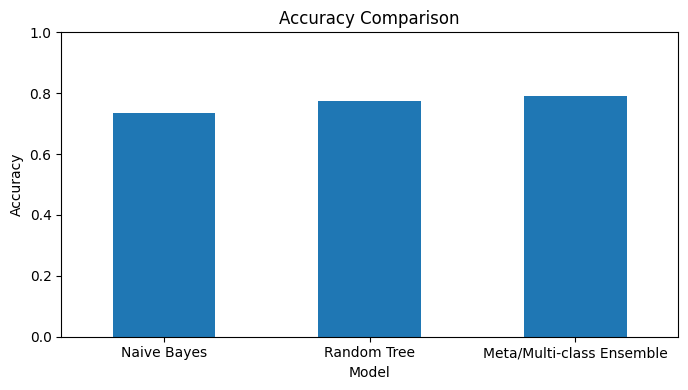

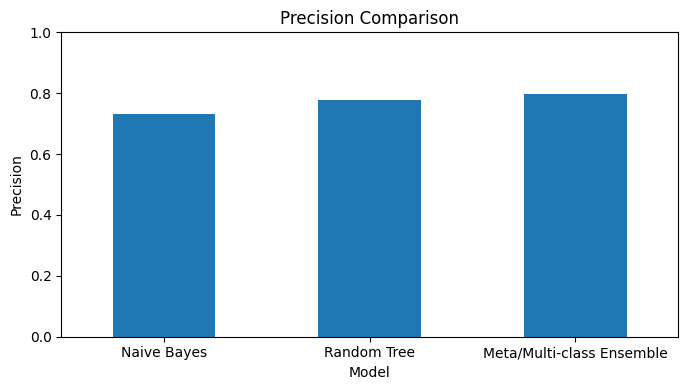

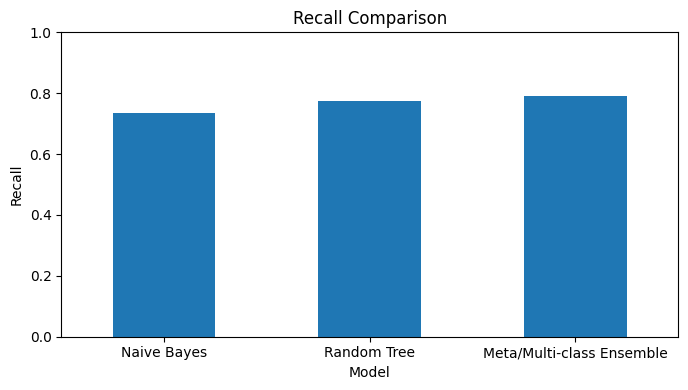

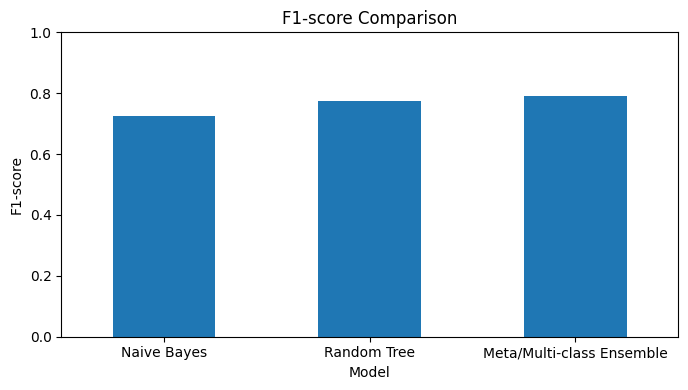

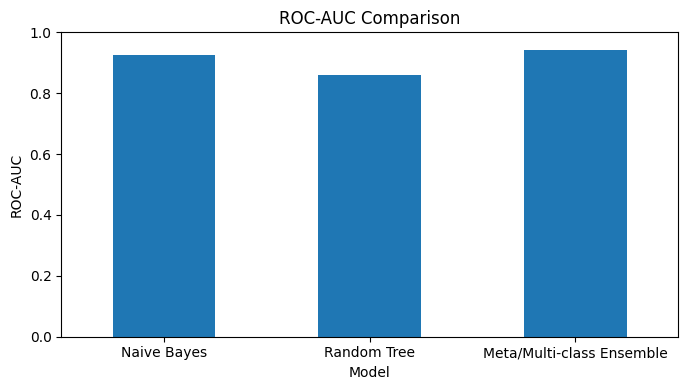

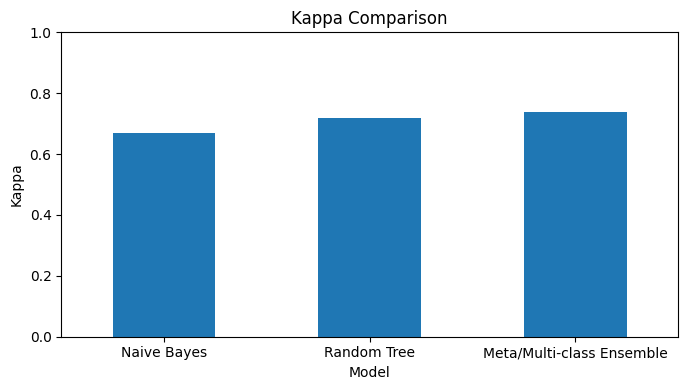

In [33]:
# Plot comparison of all evaluation metrics

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "Kappa"
]

for metric in metrics:
    
    plt.figure(figsize=(7, 4))
    
    comparison_df[metric].plot(
        kind="bar"
    )
    
    plt.title(
        f"{metric} Comparison"
    )
    
    plt.xlabel("Model")
    plt.ylabel(metric)
    
    plt.ylim(0, 1)
    
    plt.xticks(
        rotation=0
    )
    
    plt.tight_layout()
    
    plt.show()

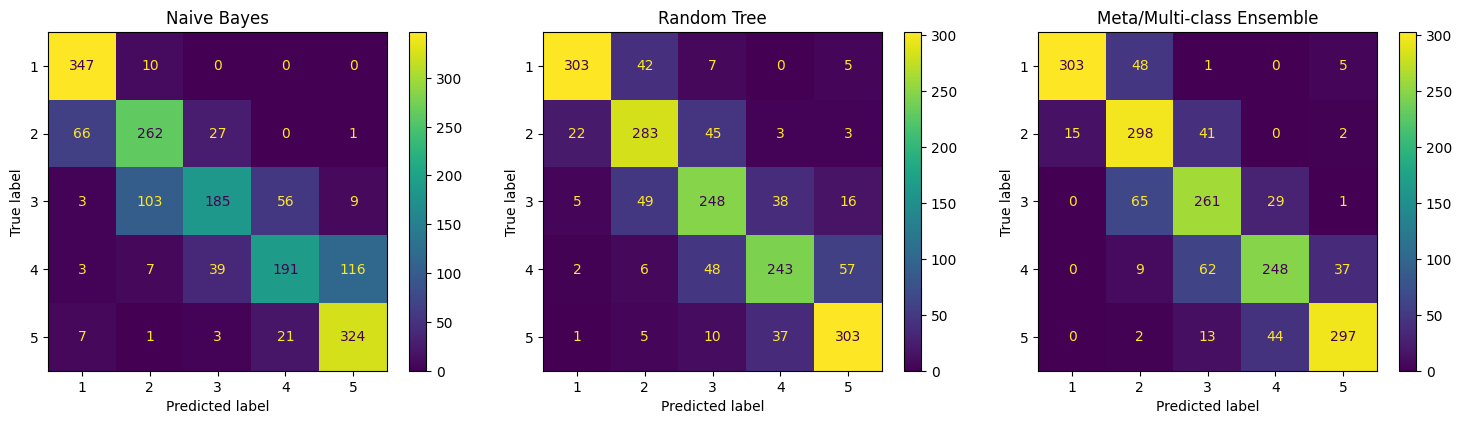

In [34]:
# Confusion matrices for all three models

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

models_and_predictions = [
    ("Naive Bayes", nb_pred),
    ("Random Tree", rt_pred),
    ("Meta/Multi-class Ensemble", meta_pred)
]

for ax, (model_name, predictions) in zip(
    axes,
    models_and_predictions
):
    
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        ax=ax
    )
    
    ax.set_title(model_name)

plt.tight_layout()

plt.show()

In [35]:
# Display final results in a clean format

print("=" * 75)
print("MODEL COMPARISON RESULTS")
print("=" * 75)

display(
    comparison_df
)

MODEL COMPARISON RESULTS


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Kappa
Model,,,,,,
Naive Bayes,0.7350,0.7320,0.7350,0.7237,0.9240,0.6687
Random Tree,0.7748,0.7768,0.7748,0.7748,0.8593,0.7186
Meta/Multi-class Ensemble,0.7900,0.7982,0.7900,0.7918,0.9404,0.7375


# Final Conclusion

The BASE PAPER classification methodology was implemented using three models:

1. Naive Bayes
2. Random Tree
3. Meta/Multi-class Ensemble

The dataset was divided into:

- 80% training data
- 20% testing data

The models were independently trained and evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Cohen's Kappa

The final comparison table and plots summarize the performance of all
three BASE PAPER models on the integrated district-level crime dataset.

The results represent the implementation of the BASE PAPER methodology
on our dataset and should not be interpreted as the exact numerical
results reported in the original paper.